# 토크나이저 비교 + 생성 파라미터 실험 + Attention 시각화

1. 여러 토크나이저로 자동차 엔진부품 도메인 문장을 분할해보고 차이를 비교
2. 동일 프롬프트에 대해 temperature / top_p를 바꿔가며 생성 결과 비교
3. BERT 계열 모델로 self-attention 시각화 (heatmap)


## 0. 환경 설정 및 패키지 설치

In [1]:
# Colab 기준 설치. 이미 설치되어 있다면 스킵해도 됩니다.
!pip install -q transformers torch sentencepiece matplotlib seaborn


In [2]:
import json
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cpu


## 1. 데이터 로드

 `reports.json`을 읽기
형식: `[{"report_id": "...", "report_text": "...", "설비종류": "...", ...}, ...]`


In [3]:
!wget https://raw.githubusercontent.com/ws-l/hh_2026_5/main/data/reports_small.json

--2026-06-22 15:23:27--  https://raw.githubusercontent.com/ws-l/hh_2026_5/main/data/reports_small.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42666 (42K) [text/plain]
Saving to: ‘reports_small.json’

reports_small.json  100%[===================>]  41.67K  --.-KB/s    in 0.01s   

2026-06-22 15:23:27 (3.54 MB/s) - ‘reports_small.json’ saved [42666/42666]



In [4]:
# Colab에서 직접 업로드하려면 아래 주석 해제

with open("reports_small.json", "r", encoding="utf-8") as f:
    reports = json.load(f)

print(f"총 {len(reports)}건 로드")
print(reports[0])


총 50건 로드
{'report_id': 'RPT-001', '설비종류': 'CNC 머신', '불량유형': '치수불량', '4M_분류': 'Machine', '심각도': '상', 'report_text': '2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 브래킷의 기준 홀 직경이 도면 12.00mm 대비 12.18mm로 측정됨을 확인함. 동일 로트 20개 중 7개에서 +0.16~+0.18mm 오차가 반복되었고 스핀들 진동은 0.18mm 수준으로 확인됨. 설비보전팀 검토 결과 스핀들 베어링 마모에 따른 런아웃 발생으로 판단됨. 베어링 점검 및 교체 후 런아웃을 재측정하고 시험 가공품 5개의 홀 직경이 12.00±0.02mm 범위인지 검증함. 심각도는 상으로 분류하며, 향후 스핀들 진동 0.12mm 초과 시 즉시 설비보전팀 점검 요청 기준을 등록함.'}


In [ ]:
# 실습용 샘플 문장 추출 (도메인 전문용어가 포함된 문장 위주로 몇 개 선정)
sample_texts = [r["report_text"] for r in reports[:5]]
for i, t in enumerate(sample_texts):
    print(f"[{i}] {t[:80]}...")


[0] 2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 브래킷의 기준 홀 직경이 도면 12.00mm 대비 12.18m...
[1] 2024년 1월 5일 14:30, CNC 머신 A-2호기에서 스테인리스 커버 외곽 절삭면에 길이 18~25mm의 미세 스크래치가 관찰됨. 절삭온...
[2] 2024년 1월 8일 10:45, CNC 머신 B-1호기 가공 후 조립된 베이스 플레이트에서 체결 볼트 2개가 지정 토크 18N·m 대비 11~...
[3] 2024년 1월 10일 16:20, 사출성형기 #1호기에서 ABS 하우징 표면 게이트 주변에 6~9mm 길이의 크랙이 발생함을 확인함. 금형온도...
[4] 2024년 1월 12일 08:50, CNC 머신 A-3호기에서 기어 하우징 포켓 깊이가 도면 8.50mm 대비 8.07~8.12mm로 얕게 가공...


## 2. 토크나이저 비교 (BPE / WordPiece / SentencePiece 계열)

토큰화 결과 비교, "실린더블록", "크랭크샤프트" 같은 전문용어에 대한 토큰화 확인


In [6]:
tokenizer_configs = {
    "GPT-2 (BPE)": "gpt2",
    "BERT-base-uncased (WordPiece)": "bert-base-uncased",
    "klue/bert-base (한국어 WordPiece)": "klue/bert-base",
    "xlm-roberta-base (SentencePiece)": "xlm-roberta-base",
}

tokenizers = {}
for name, ckpt in tokenizer_configs.items():
    try:
        tokenizers[name] = AutoTokenizer.from_pretrained(ckpt)
        print(f"로드 완료: {name}")
    except Exception as e:
        print(f"로드 실패: {name} ({e})")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

로드 완료: xlm-roberta-base (SentencePiece)


In [7]:
test_sentence = sample_texts[0]
print("원문:", test_sentence)
print("=" * 80)

for name, tok in tokenizers.items():
    tokens = tok.tokenize(test_sentence)
    print(f"\n[{name}] 토큰 수: {len(tokens)}")
    print(tokens)


원문: 2024년 1월 3일 09:15, CNC 머신 A-1호기에서 가공 완료된 알루미늄 브래킷의 기준 홀 직경이 도면 12.00mm 대비 12.18mm로 측정됨을 확인함. 동일 로트 20개 중 7개에서 +0.16~+0.18mm 오차가 반복되었고 스핀들 진동은 0.18mm 수준으로 확인됨. 설비보전팀 검토 결과 스핀들 베어링 마모에 따른 런아웃 발생으로 판단됨. 베어링 점검 및 교체 후 런아웃을 재측정하고 시험 가공품 5개의 홀 직경이 12.00±0.02mm 범위인지 검증함. 심각도는 상으로 분류하며, 향후 스핀들 진동 0.12mm 초과 시 즉시 설비보전팀 점검 요청 기준을 등록함.

[GPT-2 (BPE)] 토큰 수: 571
['20', '24', 'ë', 'ħ', 'Ħ', 'Ġ1', 'ì', 'Ľ', 'Ķ', 'Ġ3', 'ìĿ', '¼', 'Ġ09', ':', '15', ',', 'ĠC', 'NC', 'Ġë', '¨', '¸', 'ì', 'ĭ', 'ł', 'ĠA', '-', '1', 'í', 'ĺ', '¸', 'ê', '¸', '°', 'ì', 'Ĺ', 'Ĳ', 'ì', 'Ħ', 'ľ', 'Ġ', 'ê', '°', 'Ģ', 'ê', '³', 'µ', 'Ġì', 'Ļ', 'Ħ', 'ë', '£', 'Į', 'ë', 'Ĳ', 'ľ', 'Ġì', 'ķ', 'Į', 'ë', '£', '¨', 'ë', '¯', '¸', 'ë', 'Ĭ', 'Ħ', 'Ġë', '¸', 'Į', 'ë', 'ŀ', 'ĺ', 'í', 'Ĥ', '·', 'ìĿ', 'ĺ', 'Ġ', 'ê', '¸', '°', 'ì', '¤', 'Ģ', 'Ġ', 'í', 'Ļ', 'Ģ', 'Ġì', '§', 'ģ', 'ê', '²', '½', 'ìĿ', '´', 'Ġë', 'ı', 'Ħ', 'ë', '©', '´', 'Ġ12', '.', '00', 'mm', 'Ġë', 'Į', 'Ģ', 'ë', '¹', 'Ħ', 'Ġ12', '.', '18', 'mm', 'ë', '¡', 'ľ', 'Ġì', '¸', '¡', 

In [8]:
# 도메인 전문용어 단독 비교 - 어떻게 쪼개지는지 더 명확히 확인
domain_terms = ["실린더블록", "크랭크샤프트", "캠샤프트", "밸브트레인", "오토클레이브"]

for term in domain_terms:
    print(f"\n=== {term} ===")
    for name, tok in tokenizers.items():
        sub = tok.tokenize(term)
        print(f"  [{name}] {sub}")



=== 실린더블록 ===
  [GPT-2 (BPE)] ['ì', 'ĭ', '¤', 'ë', '¦', '°', 'ë', 'į', 'Ķ', 'ë', '¸', 'Ķ', 'ë', '¡', 'Ŀ']
  [BERT-base-uncased (WordPiece)] ['ᄉ', '##ᅵ', '##ᆯ', '##ᄅ', '##ᅵ', '##ᆫ', '##ᄃ', '##ᅥ', '##ᄇ', '##ᅳ', '##ᆯ', '##ᄅ', '##ᅩ', '##ᆨ']
  [klue/bert-base (한국어 WordPiece)] ['실린', '##더', '##블', '##록']
  [xlm-roberta-base (SentencePiece)] ['▁실', '린', '더', '블', '록']

=== 크랭크샤프트 ===
  [GPT-2 (BPE)] ['í', 'ģ', '¬', 'ë', 'ŀ', 'Ń', 'í', 'ģ', '¬', 'ì', 'ĥ', '¤', 'í', 'Ķ', 'Ħ', 'í', 'Ĭ', '¸']
  [BERT-base-uncased (WordPiece)] ['[UNK]']
  [klue/bert-base (한국어 WordPiece)] ['크', '##랭', '##크', '##샤', '##프트']
  [xlm-roberta-base (SentencePiece)] ['▁크', '랭', '크', '샤', '프', '트']

=== 캠샤프트 ===
  [GPT-2 (BPE)] ['ì', 'º', 'ł', 'ì', 'ĥ', '¤', 'í', 'Ķ', 'Ħ', 'í', 'Ĭ', '¸']
  [BERT-base-uncased (WordPiece)] ['[UNK]']
  [klue/bert-base (한국어 WordPiece)] ['캠', '##샤', '##프트']
  [xlm-roberta-base (SentencePiece)] ['▁', '캠', '샤', '프', '트']

=== 밸브트레인 ===
  [GPT-2 (BPE)] ['ë', '°', '¸', 'ë', '¸', 'Į', 'í', 'Ĭ', '¸'

**관찰 포인트**
- 한국어 전용 토크나이저(klue/bert-base)와 영어 기반 토크나이저(gpt2, bert-base-uncased)의 분할 차이
- 전문용어가 의미 단위로 깨지지 않고 음절/바이트 단위로 과도하게 쪼개지는 경우 확인
- 토큰 수가 많아질수록 같은 문장도 더 많은 context window를 소비함을 체감


## 3. 생성 파라미터 실험 (Temperature & Top-p)

동일 prompt에 대해 temperature, top_p를 바꿔가며 생성 결과가 어떻게 달라지는지 비교

In [9]:
gen_model_name = "skt/kogpt2-base-v2"  # 한국어 경량 생성 모델 (Colab에서 가볍게 실행 가능)

gen_tokenizer = AutoTokenizer.from_pretrained(gen_model_name)
gen_model = AutoModelForCausalLM.from_pretrained(gen_model_name).to(device)
gen_model.eval()
print("생성 모델 로드 완료")


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

생성 모델 로드 완료


In [10]:
prompt = "엔진부품 CNC 가공 공정에서 치수불량이 발생하는 주요 원인은"

def generate(prompt, temperature, top_p, max_new_tokens=60):
    inputs = gen_tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=gen_tokenizer.eos_token_id,
        )
    return gen_tokenizer.decode(output[0], skip_special_tokens=True)

settings = [
    {"temperature": 0.1, "top_p": 0.9, "label": "낮은 temperature (보수적/결정적)"},
    {"temperature": 0.7, "top_p": 0.9, "label": "중간 temperature"},
    {"temperature": 1.3, "top_p": 0.9, "label": "높은 temperature (다양/무작위)"},
    {"temperature": 0.7, "top_p": 0.5, "label": "낮은 top_p (후보 제한)"},
]

for s in settings:
    print(f"\n--- {s['label']} (temperature={s['temperature']}, top_p={s['top_p']}) ---")
    result = generate(prompt, s["temperature"], s["top_p"])
    print(result)



--- 낮은 temperature (보수적/결정적) (temperature=0.1, top_p=0.9) ---
����CNC��������������������������������������������������������������������������������

--- 중간 temperature (temperature=0.7, top_p=0.9) ---
����CNC���������������������t�

--- 높은 temperature (다양/무작위) (temperature=1.3, top_p=0.9) ---
����CNC����������������������tti▁(�i�i▁)▁/▁���n�ǔ▁(�i�▁)▁올▁시즌,▁디에고▁파드마리가▁이적해서▁리그▁17경기▁1골을▁기록했고▁2019년에도▁4골씩▁기록했다.
2012-13▁시즌에도▁1골

--- 낮은 top_p (후보 제한) (temperature=0.7, top_p=0.5) ---
����CNC�����������������������n���n���n���n���n���n���n���n���n���n���n���n���n���n���n


**관찰 포인트**
- temperature가 낮을수록 같은 prompt에서도 반복 실행 시 결과가 더 일관적
- temperature가 높아지면 문법은 유지되지만 내용이 산만해지거나 사실과 무관해질 수 있음
- 제조 QA 챗봇처럼 사실 기반 응답이 중요한 경우 낮은 temperature(0.1~0.3)를 권장하는 이유를 직접 확인


## 4. Attention 시각화

BERT 계열 모델로 self-attention 패턴을 heatmap으로 시각화합니다.

**주의:** `attn_implementation="eager"`로 명시하지 않으면 최신 transformers 버전에서 attention map을 받을 수 없음 (`sdpa` 기본값 문제).


In [11]:
attn_model_name = "klue/bert-base"

attn_tokenizer = AutoTokenizer.from_pretrained(attn_model_name)
attn_model = AutoModel.from_pretrained(
    attn_model_name,
    attn_implementation="eager",  # 필수: sdpa로는 attention 추출 불가
    output_attentions=True,
).to(device)
attn_model.eval()
print("Attention 모델 로드 완료")


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: klue/bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Attention 모델 로드 완료


In [12]:
attn_sentence = "크랭크샤프트 표면에서 크랙이 발견되어 열처리 공정을 점검했다"

inputs = attn_tokenizer(attn_sentence, return_tensors="pt").to(device)
tokens = attn_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = attn_model(**inputs)

# outputs.attentions: tuple(layer 수) of (batch, head 수, seq_len, seq_len)
attentions = outputs.attentions
print(f"레이어 수: {len(attentions)}, 헤드 수: {attentions[0].shape[1]}, 토큰 수: {len(tokens)}")
print("토큰:", tokens)


레이어 수: 12, 헤드 수: 12, 토큰 수: 22
토큰: ['[CLS]', '크', '##랭', '##크', '##샤', '##프트', '표면', '##에서', '크', '##랙', '##이', '발견', '##되', '##어', '열', '##처리', '공정', '##을', '점검', '##했', '##다', '[SEP]']


- 한글 폰트 설치

In [13]:
# 1) 나눔고딕 폰트 설치
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

# 2) matplotlib 폰트 캐시 갱신
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [14]:
#미반영시 캐시 삭제
#!rm -rf ~/.cache/matplotlib

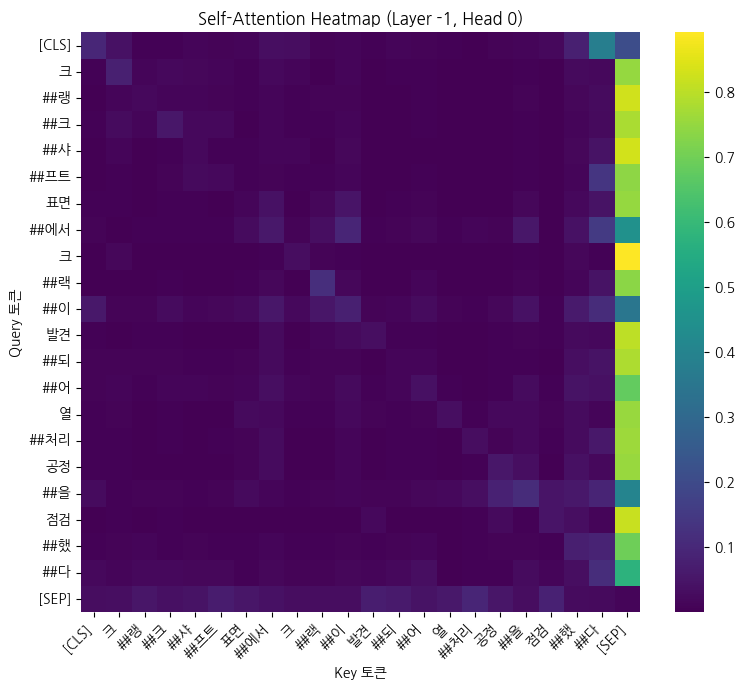

In [15]:
# 마지막 레이어의 첫 번째 head를 시각화
layer_idx = -1
head_idx = 0

attn_matrix = attentions[layer_idx][0, head_idx].cpu().numpy()

plt.figure(figsize=(8, 7))
sns.heatmap(
    attn_matrix,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis",
    cbar=True,
)
plt.title(f"Self-Attention Heatmap (Layer {layer_idx}, Head {head_idx})")
plt.xlabel("Key 토큰")
plt.ylabel("Query 토큰")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


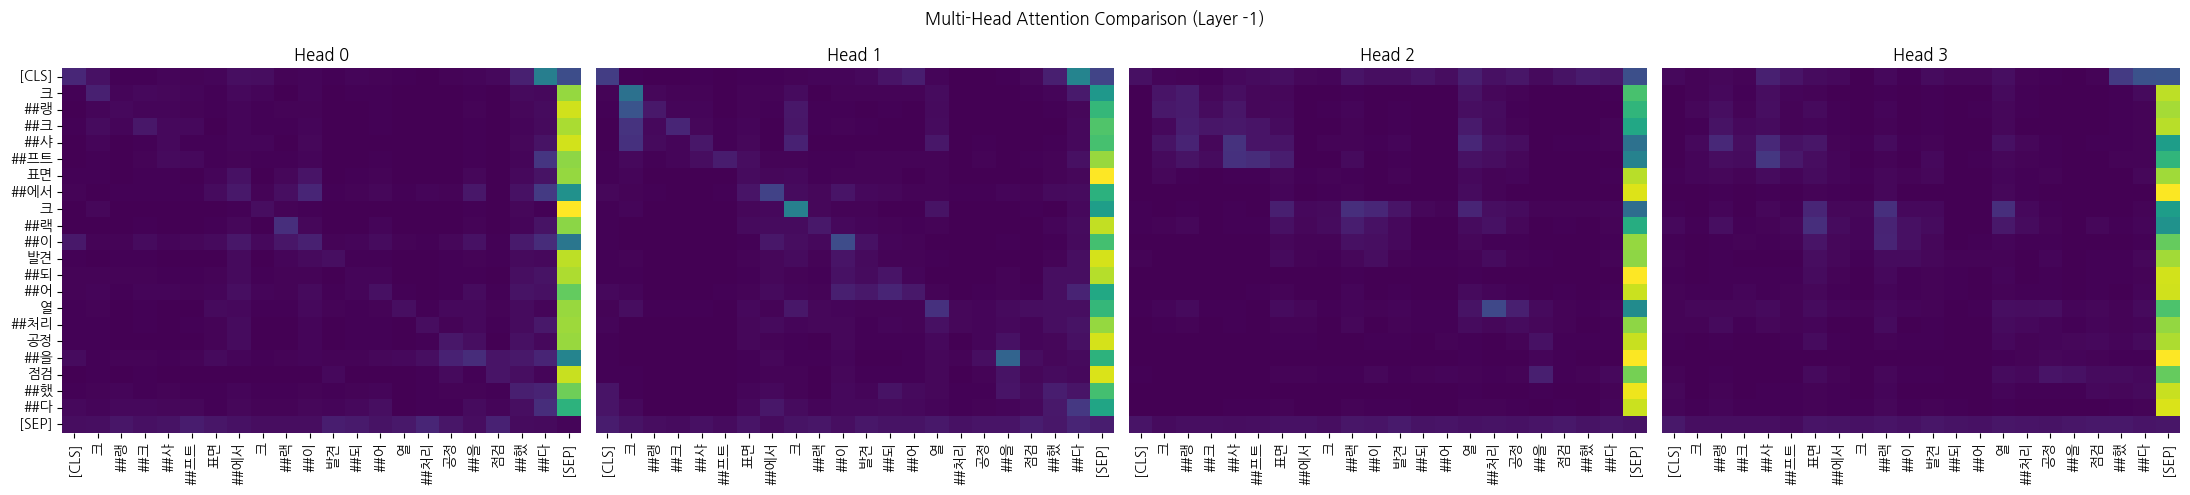

In [16]:
# 여러 head를 한 번에 비교 (같은 레이어, head 0~3)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for h in range(4):
    attn_matrix_h = attentions[layer_idx][0, h].cpu().numpy()
    sns.heatmap(
        attn_matrix_h,
        xticklabels=tokens,
        yticklabels=tokens if h == 0 else False,
        cmap="viridis",
        ax=axes[h],
        cbar=False,
    )
    axes[h].set_title(f"Head {h}")
    axes[h].tick_params(axis="x", rotation=90)

plt.suptitle(f"Multi-Head Attention Comparison (Layer {layer_idx})")
plt.tight_layout()
plt.show()


**관찰 포인트**
- "크랙"이라는 토큰이 "크랭크샤프트", "발견"과 얼마나 강하게 연결되는지 확인
- head마다 서로 다른 관점(문법적 관계 vs 의미적 관계)을 학습하는지 비교
- attention 개념이 RAG의 retrieval 단계와 연결
